# Exploratory Data Analysis -- SeNic Dataset

Surface Electromyography in Non-ideal Conditions (SeNic)
- 36 subjects, 8-channel Myo armband, 200 Hz
- 7 gestures, up to 11 electrode positions, multiple sessions
- Non-ideal factors: electrode shift, inter-day, fatigue, arm posture, individual difference

## 1. Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

from config import (
    METADATA_PATH, SAMPLING_RATE, N_CHANNELS, WINDOW_SIZE, STRIDE_SIZE,
    GESTURE_CLASSES, GESTURE_TO_LABEL, SUBJECTS_ALL,
    SUBJECTS_INTERDAY_LONG, SUBJECTS_INTERDAY_SHORT,
    SUBJECTS_NON_FATIGUE, SUBJECTS_FATIGUE,
    BANDPASS_LOW, BANDPASS_HIGH,
)
from src.preprocessing import load_trial_windows, load_raw_trial, filter_signal, skip_rest_transition
from src.data_splitter import load_metadata

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
})
palette = sns.color_palette("tab10", 10)
meta = load_metadata(valid_only=False)
meta_valid = meta[meta["is_valid"] == True].copy()
print(f"Total trials in metadata: {len(meta):,}")
print(f"Valid trials: {len(meta_valid):,}")
print(f"Invalid trials: {(~meta['is_valid']).sum():,}")
print(f"Columns: {list(meta.columns)}")

Total trials in metadata: 24,486
Valid trials: 24,457
Invalid trials: 29
Columns: ['subject', 'session', 'position', 'repetition', 'gesture', 'gesture_label', 'gender', 'age', 'description', 'direction', 'is_fatigue', 'raw_file_path', 'window_file_path', 'n_windows', 'is_valid']


## 2. Dataset Overview

In [2]:
n_subjects = meta_valid["subject"].nunique()
n_sessions = meta_valid.groupby("subject")["session"].nunique()
n_gestures = meta_valid["gesture"].nunique()
n_positions = meta_valid["position"].nunique()
total_windows = meta_valid["n_windows"].sum()
duration_sec = total_windows * STRIDE_SIZE / SAMPLING_RATE

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Subjects:            {n_subjects}")
print(f"  Gestures:            {n_gestures}")
print(f"  Max positions/sess:  {n_positions}")
print(f"  Repetitions/gesture: 3")
print(f"  Channels:            {N_CHANNELS}")
print(f"  Sampling rate:       {SAMPLING_RATE} Hz")
print(f"  Bandpass filter:     {BANDPASS_LOW}-{BANDPASS_HIGH} Hz")
print(f"  Window size:         {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLING_RATE*1000:.0f} ms)")
print(f"  Stride:              {STRIDE_SIZE} samples ({STRIDE_SIZE/SAMPLING_RATE*1000:.0f} ms)")
print(f"  Valid trials:        {len(meta_valid):,}")
print(f"  Total windows:       {int(total_windows):,}")
print(f"  Est. signal hours:   {duration_sec/3600:.1f} h")
print("=" * 55)

  DATASET OVERVIEW
  Subjects:            36
  Gestures:            7
  Max positions/sess:  11
  Repetitions/gesture: 3
  Channels:            8
  Sampling rate:       200 Hz
  Bandpass filter:     20.0-95.0 Hz
  Window size:         50 samples (250 ms)
  Stride:              10 samples (50 ms)
  Valid trials:        24,457
  Total windows:       2,792,999
  Est. signal hours:   38.8 h


## 3. Subject Demographics

Gender distribution: {'M': 25, 'F': 11}
Age range: 22-31 (mean 24.6 +/- 2.3)
Description breakdown: {'RI': 18, 'RO': 6, 'RM': 6, 'FA': 6}
Fatigue subjects: ['h30', 'h31', 'h32', 'h33', 'h34', 'h35']
Interday-long (10 sess): ['h0', 'h1', 'h2', 'h3', 'h4', 'h5']
Interday-short (3 sess): ['h6', 'h7', 'h8', 'h9', 'h10', 'h11', 'h12', 'h13']


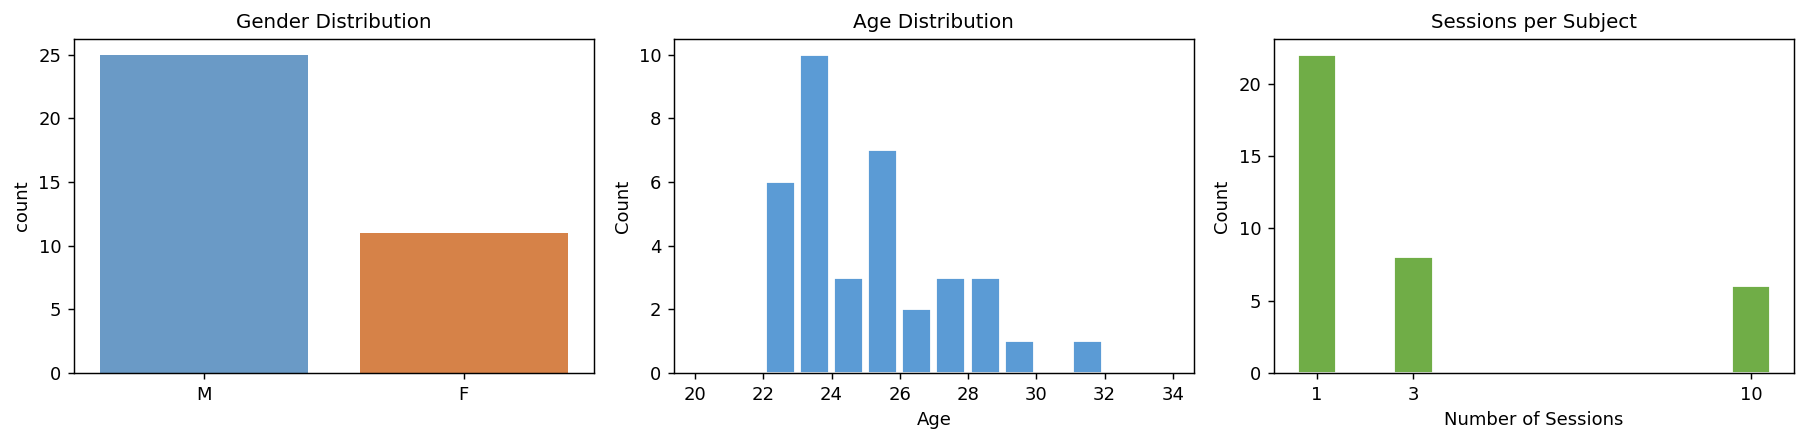

In [3]:
subj_info = meta_valid.groupby("subject").first()[
    ["gender", "age", "description", "is_fatigue"]
].reset_index()
subj_info["sessions"] = meta_valid.groupby("subject")["session"].nunique().values

print(f"Gender distribution: {dict(Counter(subj_info['gender']))}")
print(f"Age range: {subj_info['age'].min()}-{subj_info['age'].max()} "
      f"(mean {subj_info['age'].mean():.1f} +/- {subj_info['age'].std():.1f})")
print(f"Description breakdown: {dict(Counter(subj_info['description']))}")
print(f"Fatigue subjects: {subj_info[subj_info['is_fatigue']]['subject'].tolist()}")
print(f"Interday-long (10 sess): {SUBJECTS_INTERDAY_LONG}")
print(f"Interday-short (3 sess): {SUBJECTS_INTERDAY_SHORT}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

sns.countplot(data=subj_info, x="gender", ax=axes[0], hue="gender", palette=["#5B9BD5", "#ED7D31"], legend=False)
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("")

axes[1].hist(subj_info["age"], bins=range(20, 35), color="#5B9BD5", edgecolor="white", rwidth=0.85)
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

sess_counts = subj_info["sessions"].value_counts().sort_index()
axes[2].bar(sess_counts.index, sess_counts.values, color="#70AD47", edgecolor="white")
axes[2].set_title("Sessions per Subject")
axes[2].set_xlabel("Number of Sessions")
axes[2].set_ylabel("Count")
axes[2].set_xticks(sess_counts.index)

plt.tight_layout()
plt.show()

### Subject Categories by Experimental Condition

In [4]:
categories = {
    "RI (Rotate Inward, large)": [s for s in SUBJECTS_NON_FATIGUE
                                   if subj_info[subj_info["subject"]==s]["description"].values[0] == "RI"
                                   and s not in [f"h{i}" for i in range(24,30)]],
    "RO (Rotate Outward)": [s for s in SUBJECTS_NON_FATIGUE
                             if subj_info[subj_info["subject"]==s]["description"].values[0] == "RO"],
    "RM (Small angle rotation)": [f"h{i}" for i in range(24,30)],
    "FE (Fatigue Enhanced)": list(SUBJECTS_FATIGUE),
}

for cat, subjs in categories.items():
    sess = [int(subj_info[subj_info["subject"]==s]["sessions"].values[0]) for s in subjs if s in subj_info["subject"].values]
    print(f"{cat}: {len(subjs)} subjects, sessions={sess[:5]}{'...' if len(sess)>5 else ''}")
    print(f"  -> {subjs}")

RI (Rotate Inward, large): 18 subjects, sessions=[10, 10, 10, 10, 10]...
  -> ['h0', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8', 'h9', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h16', 'h17']
RO (Rotate Outward): 6 subjects, sessions=[1, 1, 1, 1, 1]...
  -> ['h18', 'h19', 'h20', 'h21', 'h22', 'h23']
RM (Small angle rotation): 6 subjects, sessions=[1, 1, 1, 1, 1]...
  -> ['h24', 'h25', 'h26', 'h27', 'h28', 'h29']
FE (Fatigue Enhanced): 6 subjects, sessions=[1, 1, 1, 1, 1]...
  -> ['h30', 'h31', 'h32', 'h33', 'h34', 'h35']


## 4. Class Distribution

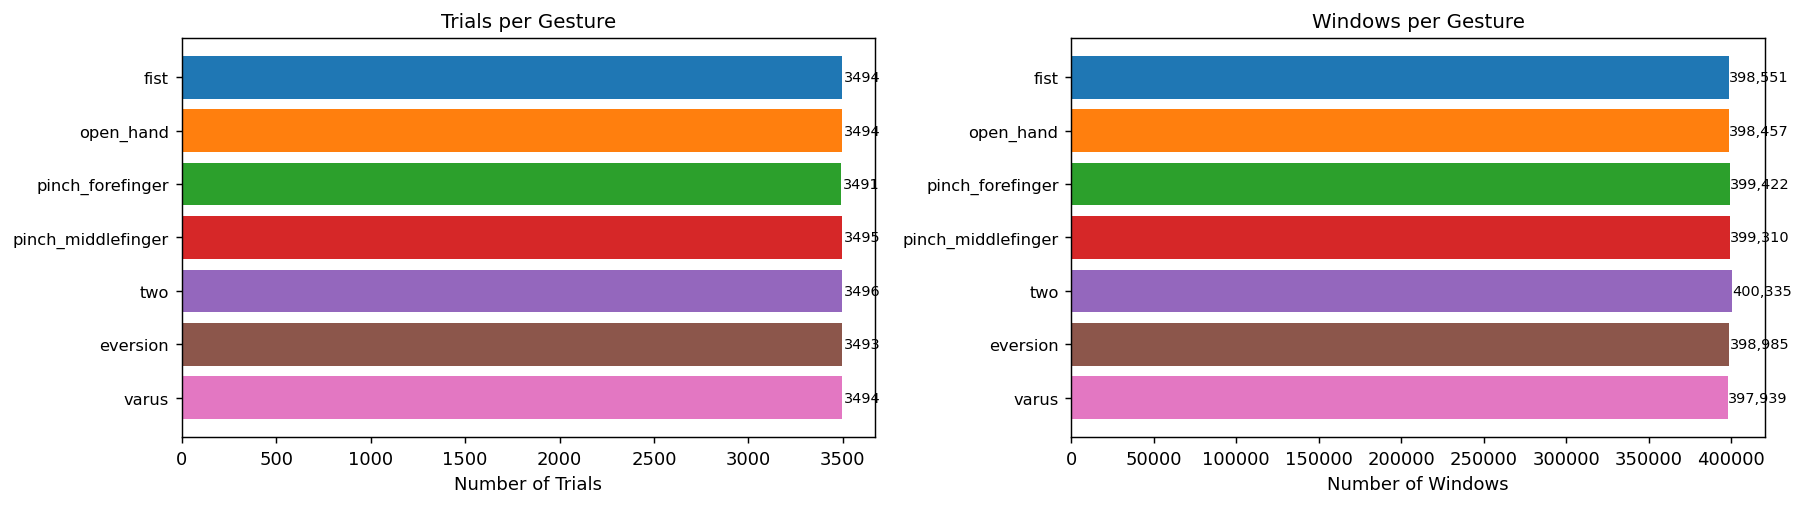

Class imbalance ratio (max/min windows): 1.01


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trial_counts = meta_valid["gesture"].value_counts()
gesture_order = [g for g, _ in sorted(GESTURE_TO_LABEL.items(), key=lambda x: x[1])]
trial_counts = trial_counts.reindex(gesture_order)

axes[0].barh(range(len(trial_counts)), trial_counts.values, color=palette[:len(trial_counts)])
axes[0].set_yticks(range(len(trial_counts)))
axes[0].set_yticklabels(trial_counts.index, fontsize=9)
axes[0].set_xlabel("Number of Trials")
axes[0].set_title("Trials per Gesture")
axes[0].invert_yaxis()
for i, v in enumerate(trial_counts.values):
    axes[0].text(v + 10, i, str(v), va="center", fontsize=8)

window_counts = meta_valid.groupby("gesture")["n_windows"].sum().reindex(gesture_order)
axes[1].barh(range(len(window_counts)), window_counts.values, color=palette[:len(window_counts)])
axes[1].set_yticks(range(len(window_counts)))
axes[1].set_yticklabels(window_counts.index, fontsize=9)
axes[1].set_xlabel("Number of Windows")
axes[1].set_title("Windows per Gesture")
axes[1].invert_yaxis()
for i, v in enumerate(window_counts.values):
    axes[1].text(v + 100, i, f"{int(v):,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

imbalance = window_counts.max() / window_counts.min()
print(f"Class imbalance ratio (max/min windows): {imbalance:.2f}")

## 5. Data Volume per Subject

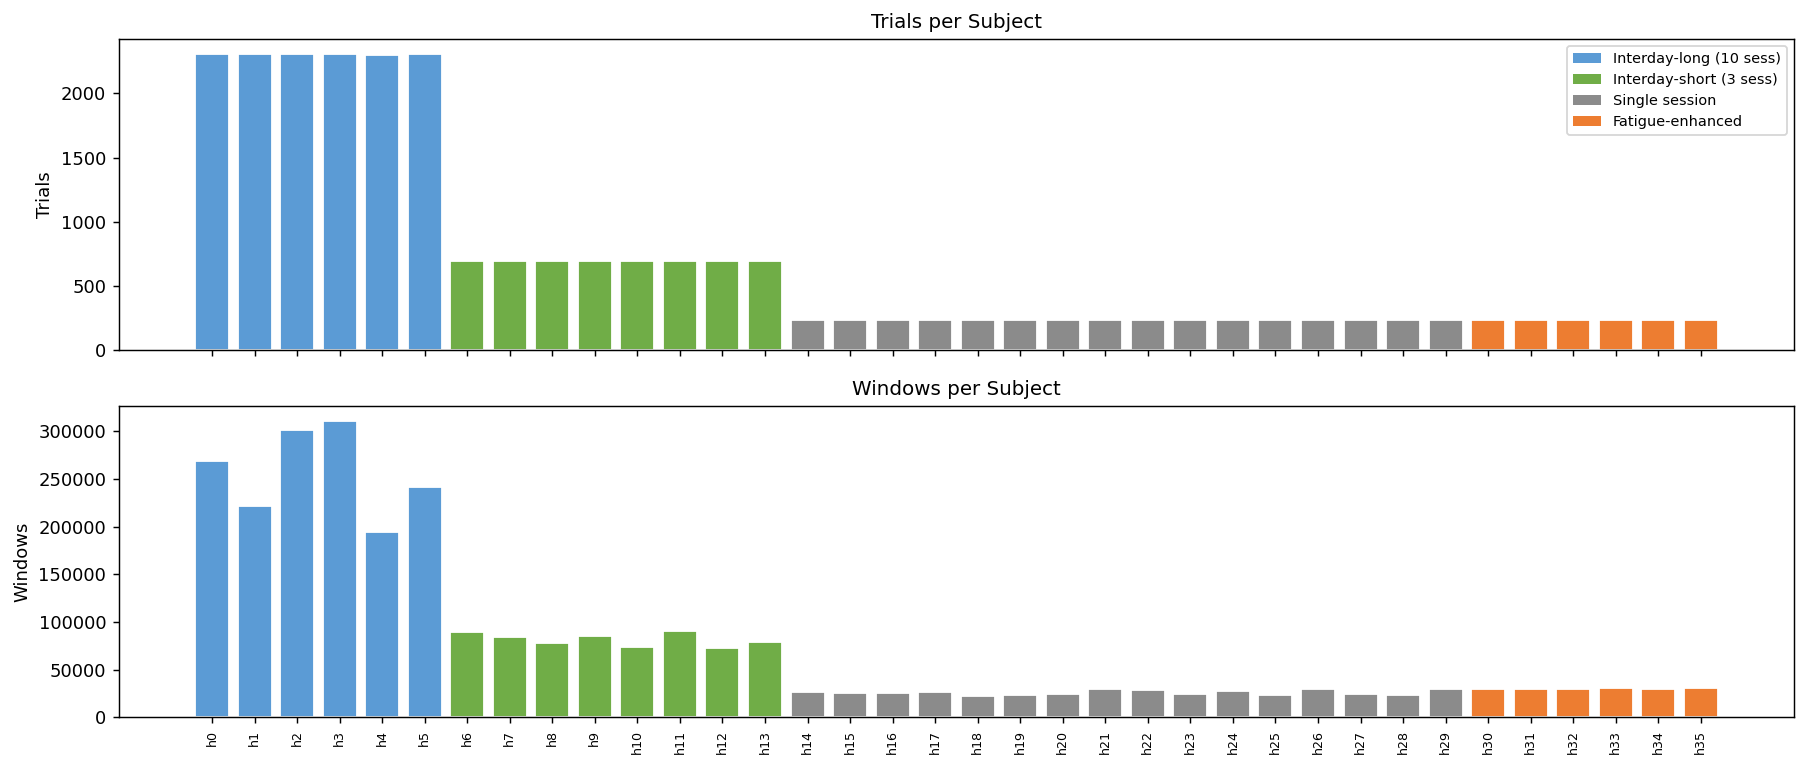

In [6]:
subj_order = sorted(meta_valid["subject"].unique(), key=lambda x: int(x[1:]))
trials_per_subj = meta_valid.groupby("subject").size().reindex(subj_order)
windows_per_subj = meta_valid.groupby("subject")["n_windows"].sum().reindex(subj_order)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

colors_bar = []
for s in subj_order:
    if s in SUBJECTS_FATIGUE:
        colors_bar.append("#ED7D31")
    elif s in SUBJECTS_INTERDAY_LONG:
        colors_bar.append("#5B9BD5")
    elif s in SUBJECTS_INTERDAY_SHORT:
        colors_bar.append("#70AD47")
    else:
        colors_bar.append("#8B8B8B")

axes[0].bar(range(len(subj_order)), trials_per_subj.values, color=colors_bar, edgecolor="white")
axes[0].set_ylabel("Trials")
axes[0].set_title("Trials per Subject")

axes[1].bar(range(len(subj_order)), windows_per_subj.values, color=colors_bar, edgecolor="white")
axes[1].set_ylabel("Windows")
axes[1].set_title("Windows per Subject")
axes[1].set_xticks(range(len(subj_order)))
axes[1].set_xticklabels(subj_order, rotation=90, fontsize=7)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#5B9BD5", label="Interday-long (10 sess)"),
    Patch(facecolor="#70AD47", label="Interday-short (3 sess)"),
    Patch(facecolor="#8B8B8B", label="Single session"),
    Patch(facecolor="#ED7D31", label="Fatigue-enhanced"),
]
axes[0].legend(handles=legend_elements, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Raw Signal Visualization

### 6.1 Single Trial -- Raw vs Filtered

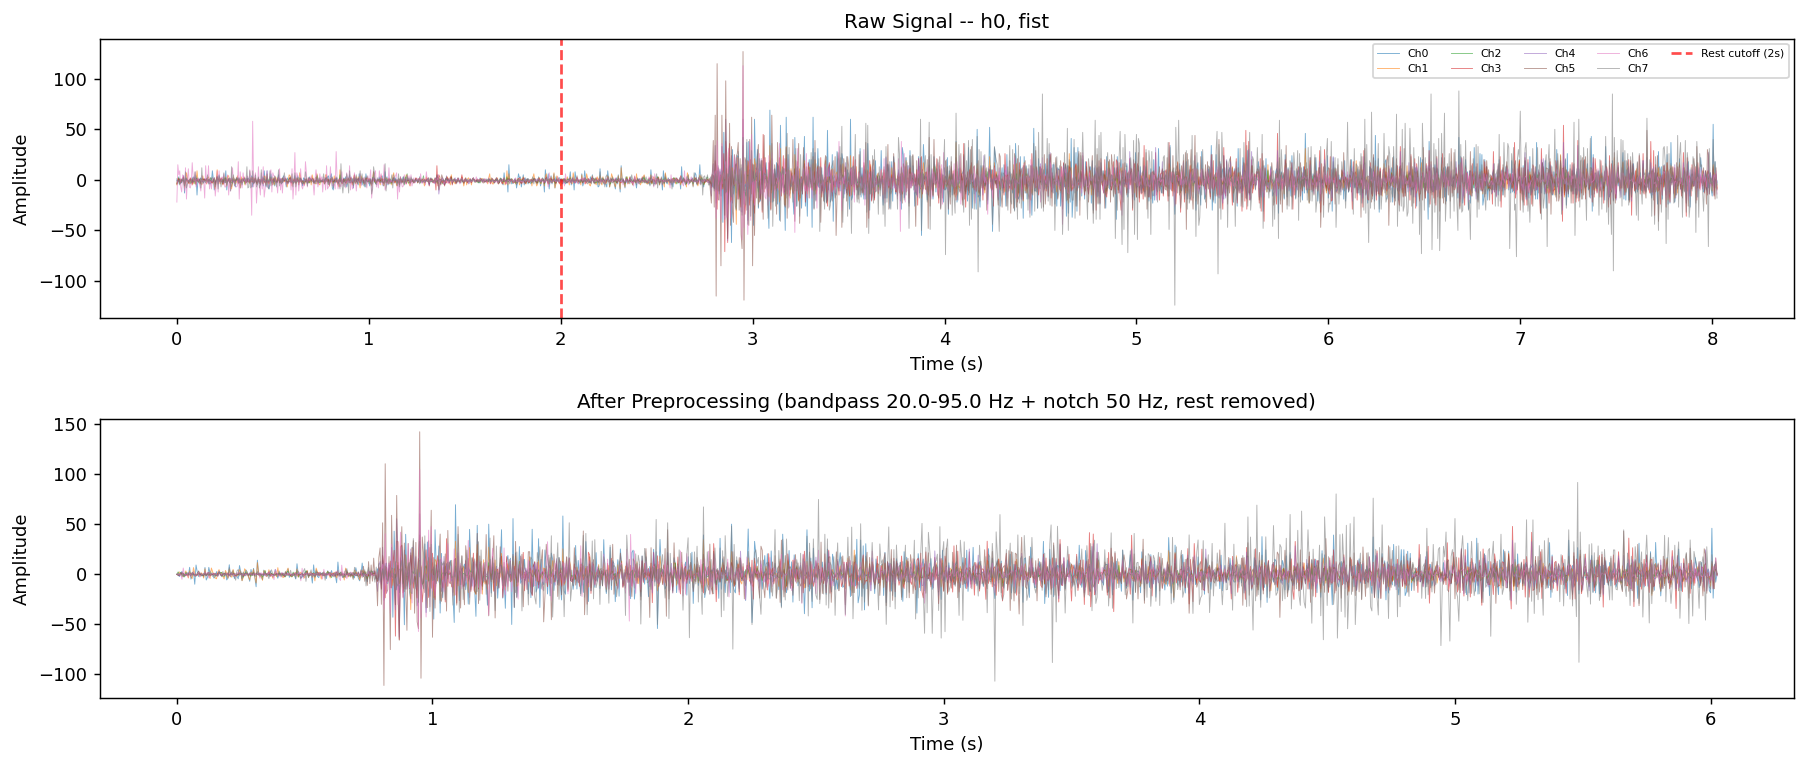

In [7]:
sample_trial = meta_valid[
    (meta_valid["subject"] == "h0") & (meta_valid["session"] == 0)
    & (meta_valid["position"] == 0) & (meta_valid["repetition"] == 0)
    & (meta_valid["gesture"] == "fist")
].iloc[0]

raw = load_raw_trial(sample_trial["raw_file_path"])
raw_skipped = skip_rest_transition(raw)
filtered = filter_signal(raw_skipped)

time_raw = np.arange(raw.shape[0]) / SAMPLING_RATE
time_filt = np.arange(filtered.shape[0]) / SAMPLING_RATE

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ch in range(N_CHANNELS):
    axes[0].plot(time_raw, raw[:, ch], alpha=0.6, linewidth=0.5, label=f"Ch{ch}")
axes[0].set_title(f"Raw Signal -- {sample_trial['subject']}, {sample_trial['gesture']}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].axvline(x=2.0, color="red", ls="--", alpha=0.7, label="Rest cutoff (2s)")
axes[0].legend(loc="upper right", fontsize=6, ncol=5)

for ch in range(N_CHANNELS):
    axes[1].plot(time_filt, filtered[:, ch], alpha=0.6, linewidth=0.5)
axes[1].set_title(f"After Preprocessing (bandpass {BANDPASS_LOW}-{BANDPASS_HIGH} Hz + notch 50 Hz, rest removed)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

### 6.2 All Gestures -- Subject h0, Position 0, Repetition 0

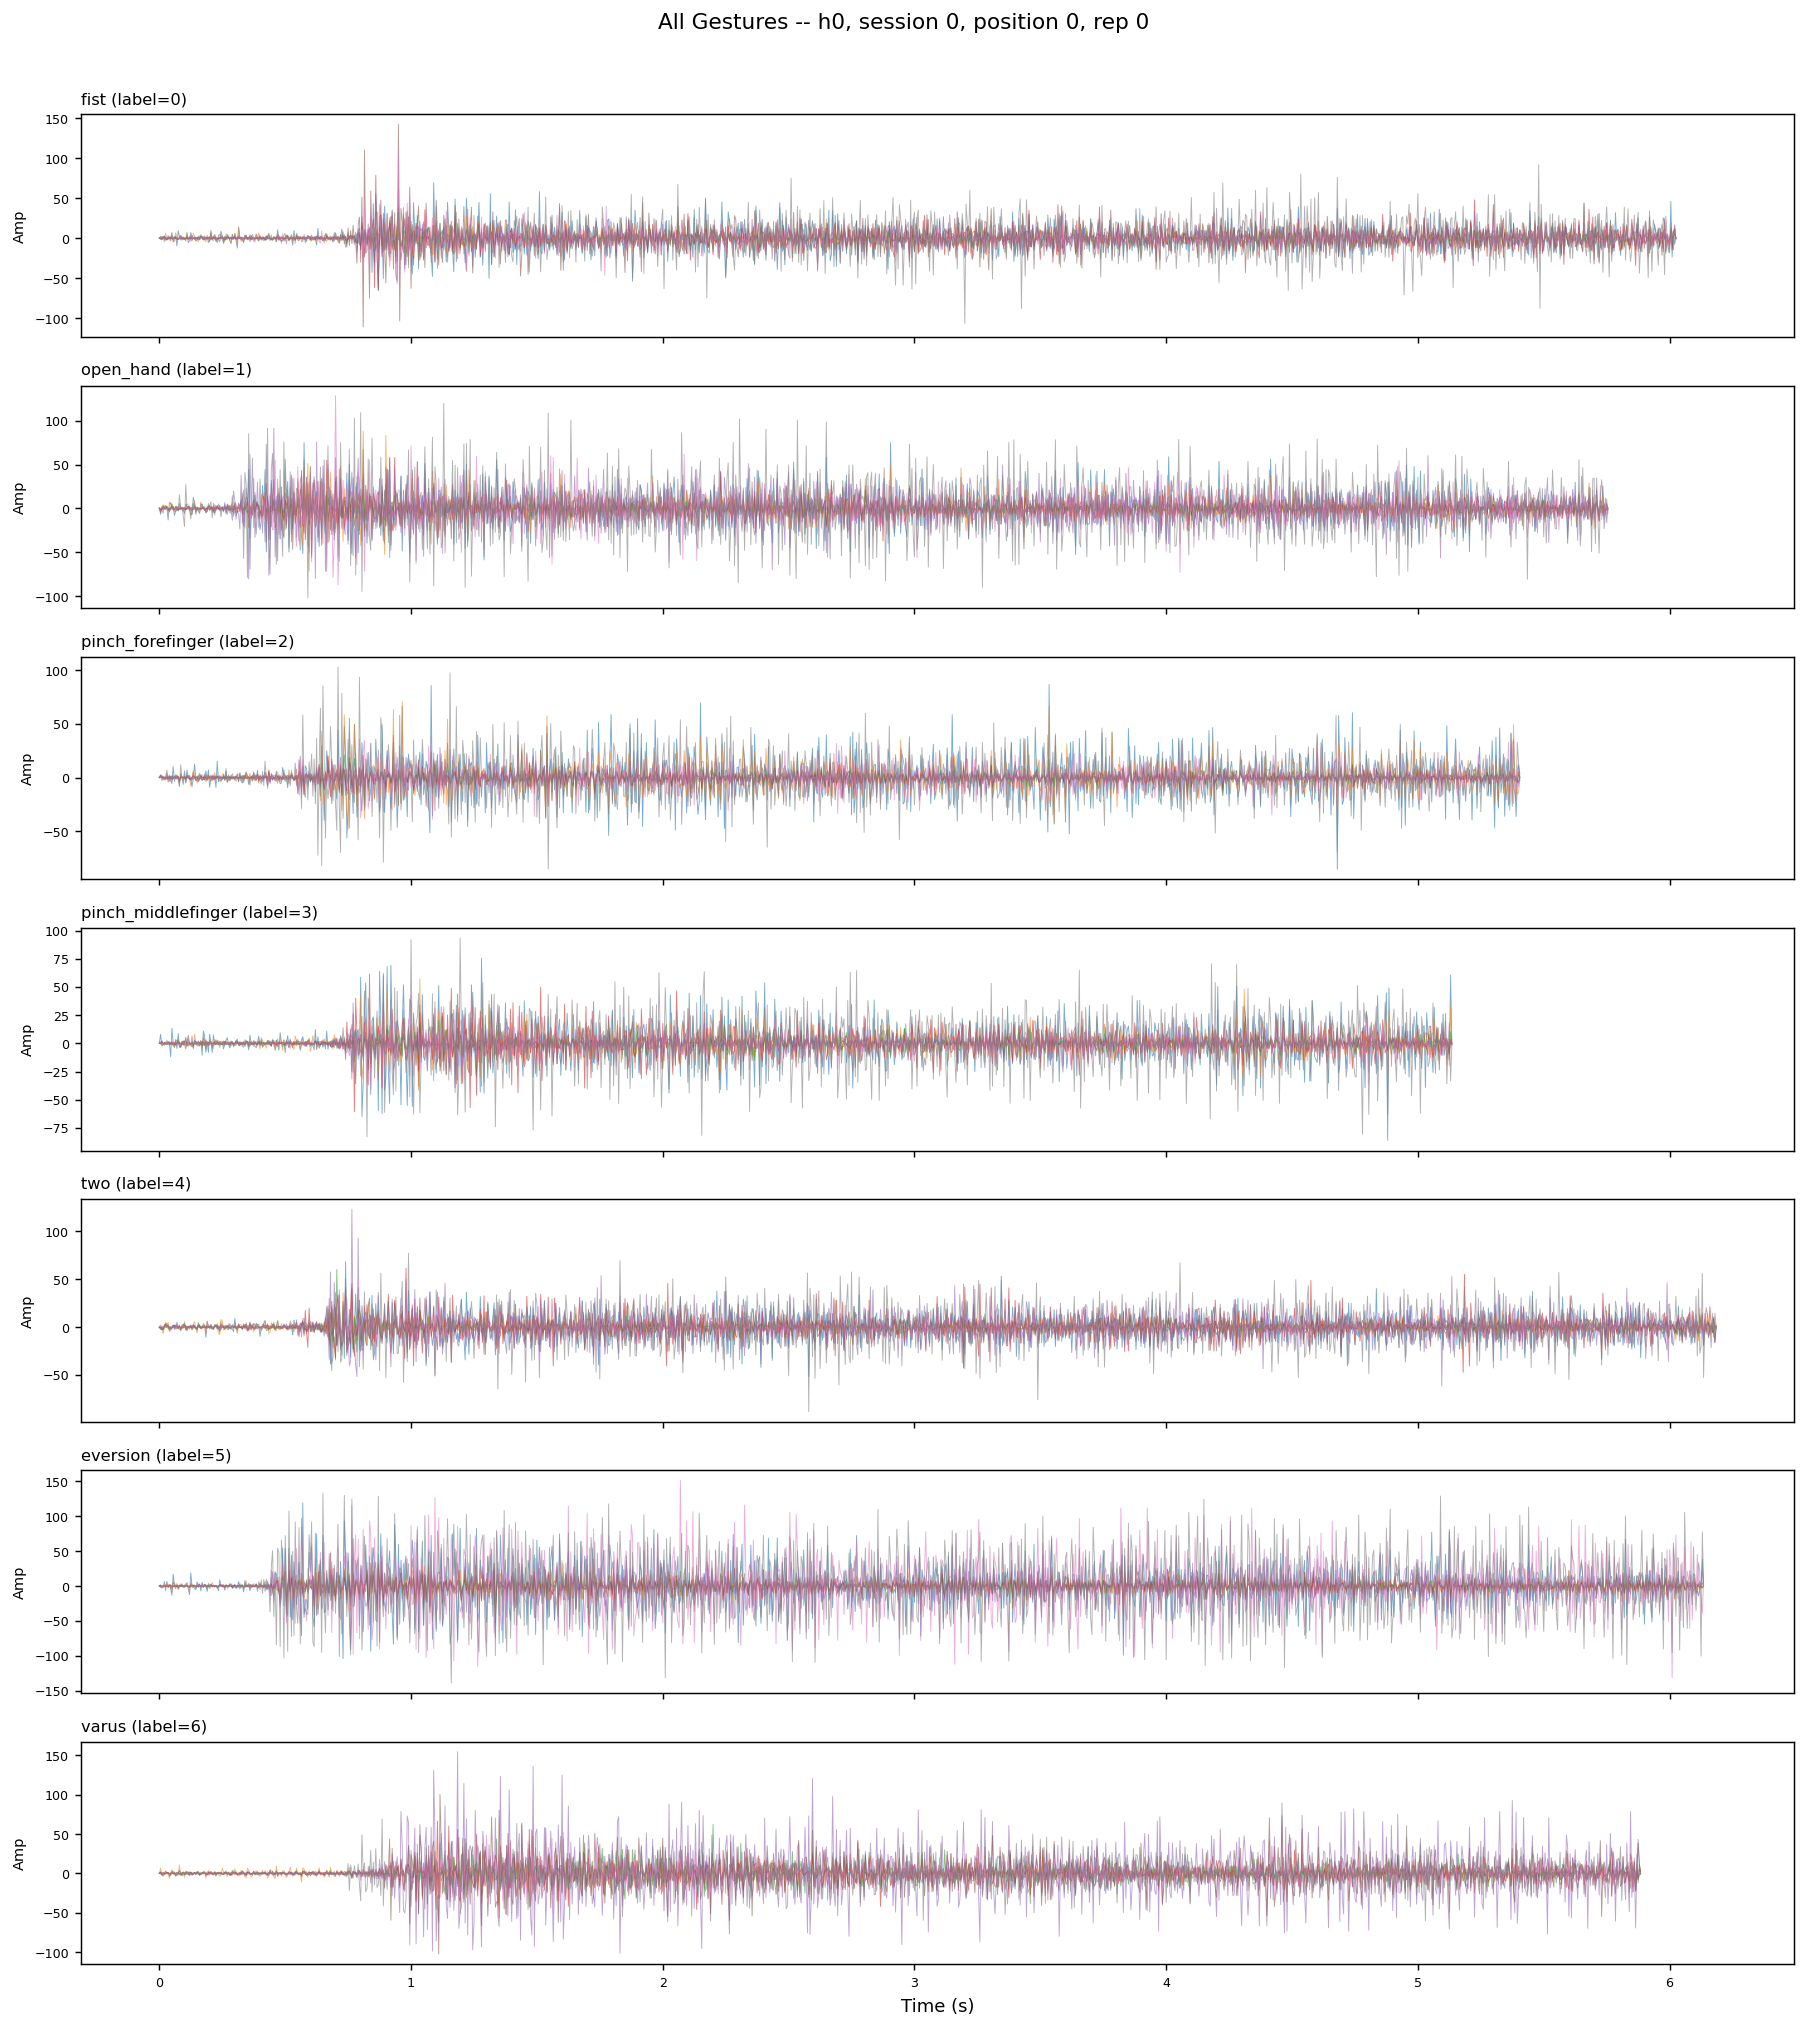

In [8]:
gesture_order = sorted(GESTURE_TO_LABEL.items(), key=lambda x: x[1])
fig, axes = plt.subplots(len(gesture_order), 1, figsize=(14, 2.2 * len(gesture_order)), sharex=True)

for idx, (gesture_name, label) in enumerate(gesture_order):
    row = meta_valid[
        (meta_valid["subject"] == "h0") & (meta_valid["session"] == 0)
        & (meta_valid["position"] == 0) & (meta_valid["repetition"] == 0)
        & (meta_valid["gesture"] == gesture_name)
    ]
    if len(row) == 0:
        axes[idx].set_title(f"{gesture_name} (label={label}) -- not found")
        continue
    row = row.iloc[0]
    raw = load_raw_trial(row["raw_file_path"])
    sig = filter_signal(skip_rest_transition(raw))
    t = np.arange(sig.shape[0]) / SAMPLING_RATE

    for ch in range(N_CHANNELS):
        axes[idx].plot(t, sig[:, ch], alpha=0.6, linewidth=0.5)
    axes[idx].set_title(f"{gesture_name} (label={label})", fontsize=9, loc="left")
    axes[idx].set_ylabel("Amp", fontsize=8)
    axes[idx].tick_params(labelsize=7)

axes[-1].set_xlabel("Time (s)")
plt.suptitle("All Gestures -- h0, session 0, position 0, rep 0", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 6.3 Preprocessed Windows (8 x 50)

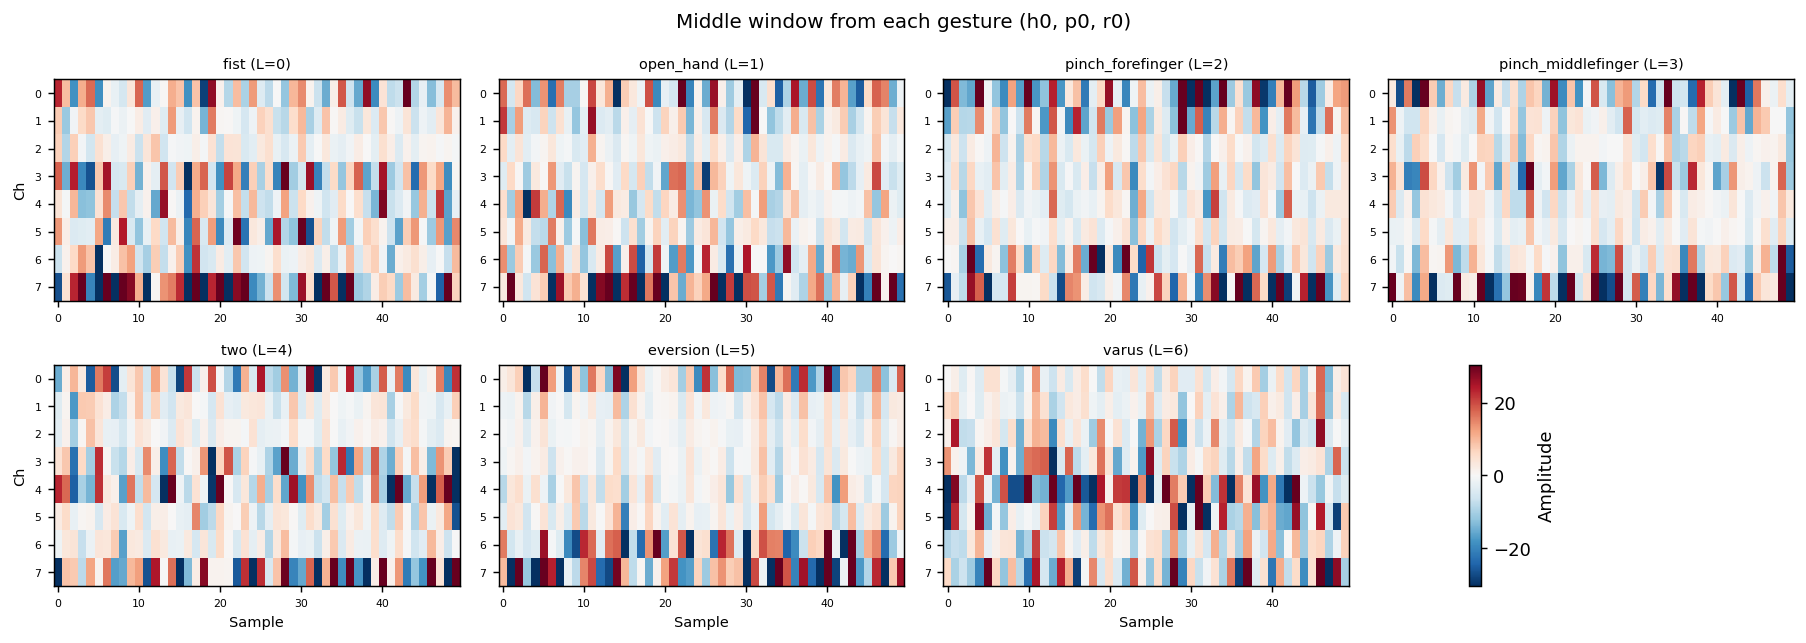

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 5))

sample_rows = meta_valid[
    (meta_valid["subject"] == "h0") & (meta_valid["session"] == 0)
    & (meta_valid["position"] == 0) & (meta_valid["repetition"] == 0)
].sort_values("gesture_label")

for idx, (_, row) in enumerate(sample_rows.iterrows()):
    if idx >= 7:
        break
    ax = axes[idx // 4, idx % 4]
    windows, labels = load_trial_windows(row["window_file_path"])
    mid = len(windows) // 2
    w = windows[mid]
    im = ax.imshow(w, aspect="auto", cmap="RdBu_r", interpolation="nearest",
                   vmin=-np.percentile(np.abs(w), 95), vmax=np.percentile(np.abs(w), 95))
    ax.set_title(f"{row['gesture']} (L={row['gesture_label']})", fontsize=8)
    ax.set_ylabel("Ch" if idx % 4 == 0 else "", fontsize=8)
    ax.set_xlabel("Sample" if idx >= 4 else "", fontsize=8)
    ax.tick_params(labelsize=6)

axes[1, 3].axis("off")
fig.colorbar(im, ax=axes[1, 3], fraction=0.8, label="Amplitude")
plt.suptitle("Middle window from each gesture (h0, p0, r0)", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Inter-Subject Variability

One of the key challenges in sEMG recognition.
Different subjects exhibit vastly different signal amplitudes due to body composition, skin impedance, and muscle activation patterns.

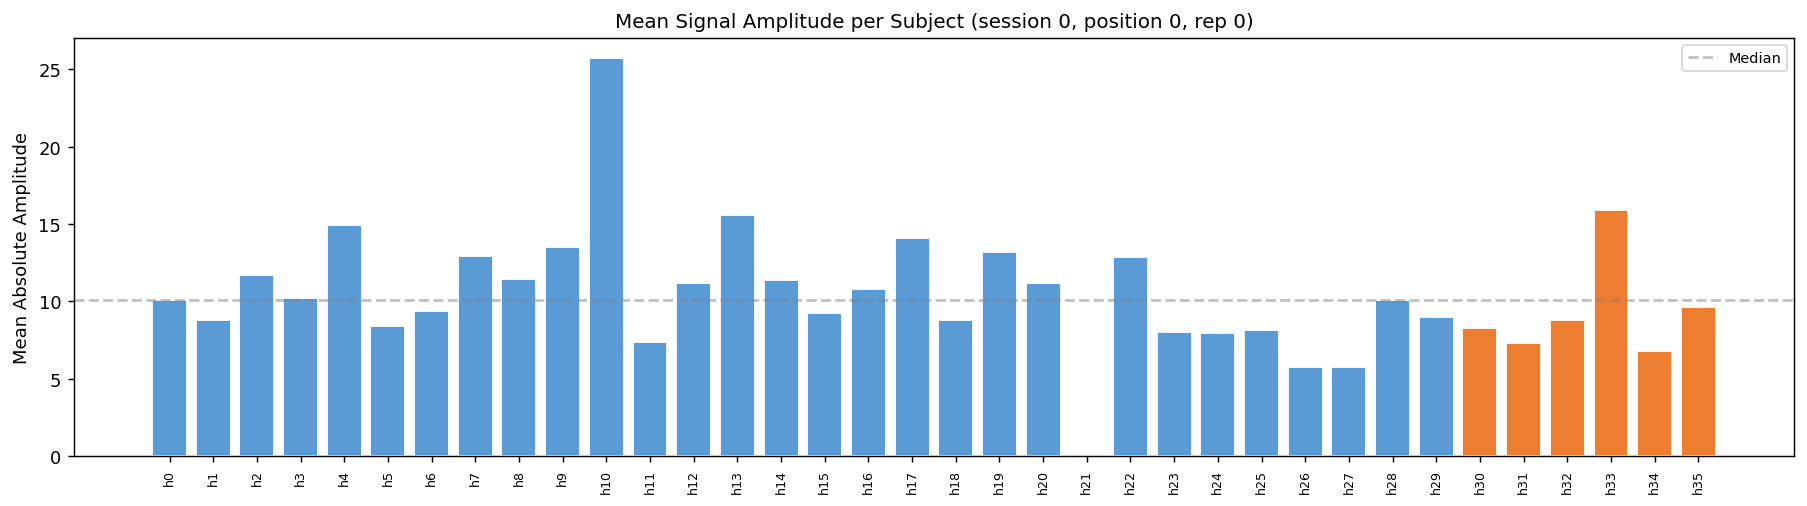

Amplitude ratio (max/min subject): 4.5x
Std of amplitudes: 3.73
CV (coefficient of variation): 34.8%


In [10]:
subj_order = sorted(meta_valid["subject"].unique(), key=lambda x: int(x[1:]))
subj_amps = []

for subj in subj_order:
    rows = meta_valid[
        (meta_valid["subject"] == subj) & (meta_valid["session"] == 0)
        & (meta_valid["position"] == 0) & (meta_valid["repetition"] == 0)
    ]
    if len(rows) == 0:
        continue
    amps = []
    for _, row in rows.head(7).iterrows():
        try:
            w, _ = load_trial_windows(row["window_file_path"])
            amps.append(np.mean(np.abs(w)))
        except Exception:
            continue
    if amps:
        subj_amps.append({"subject": subj, "mean_abs_amp": np.mean(amps),
                          "is_fatigue": subj in SUBJECTS_FATIGUE})

amp_df = pd.DataFrame(subj_amps)

fig, ax = plt.subplots(figsize=(14, 4))
colors_amp = ["#ED7D31" if r["is_fatigue"] else "#5B9BD5" for _, r in amp_df.iterrows()]
ax.bar(range(len(amp_df)), amp_df["mean_abs_amp"], color=colors_amp, edgecolor="white")
ax.set_xticks(range(len(amp_df)))
ax.set_xticklabels(amp_df["subject"], rotation=90, fontsize=7)
ax.set_ylabel("Mean Absolute Amplitude")
ax.set_title("Mean Signal Amplitude per Subject (session 0, position 0, rep 0)")
ax.axhline(amp_df["mean_abs_amp"].median(), color="gray", ls="--", alpha=0.5, label="Median")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ratio = amp_df["mean_abs_amp"].max() / amp_df["mean_abs_amp"].min()
print(f"Amplitude ratio (max/min subject): {ratio:.1f}x")
print(f"Std of amplitudes: {amp_df['mean_abs_amp'].std():.2f}")
print(f"CV (coefficient of variation): {amp_df['mean_abs_amp'].std() / amp_df['mean_abs_amp'].mean() * 100:.1f}%")

## 8. Electrode Shift Effect on Signal

The Myo armband is rotated around the forearm between positions.
This changes which muscles each channel records, drastically altering signal patterns.

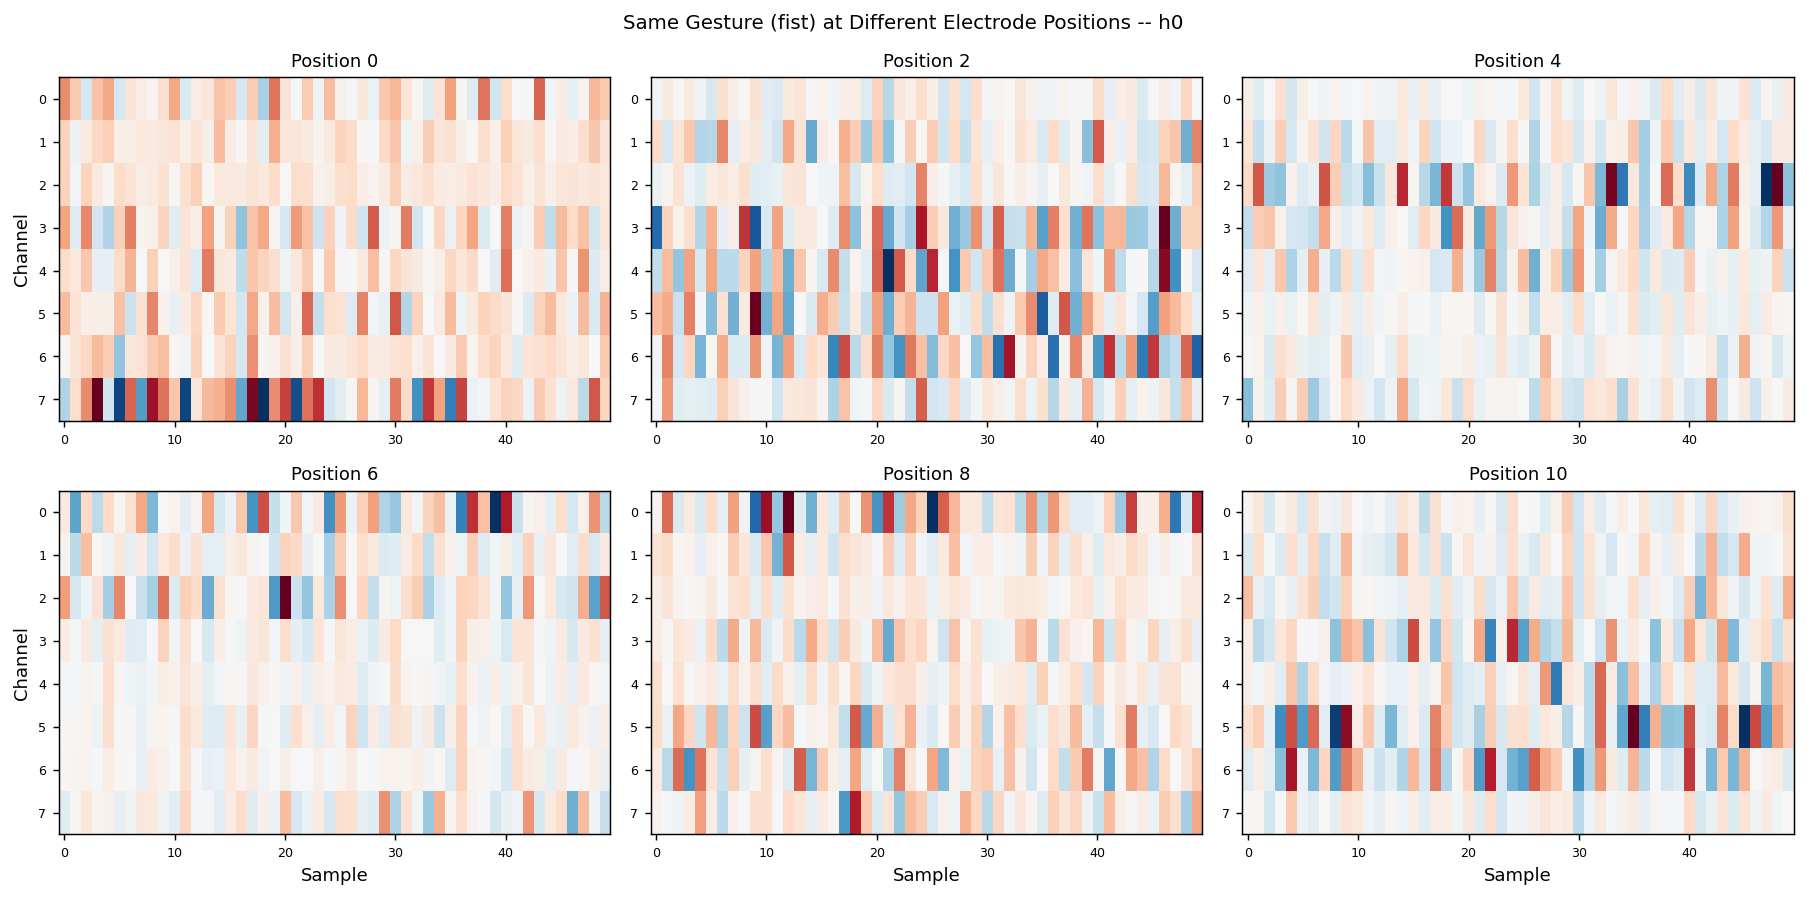

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

sample_subj = "h0"
sample_gesture = "fist"
positions_to_show = [0, 2, 4, 6, 8, 10]

for idx, pos in enumerate(positions_to_show):
    ax = axes[idx // 3, idx % 3]
    row = meta_valid[
        (meta_valid["subject"] == sample_subj) & (meta_valid["session"] == 0)
        & (meta_valid["position"] == pos) & (meta_valid["repetition"] == 0)
        & (meta_valid["gesture"] == sample_gesture)
    ]
    if len(row) == 0:
        ax.set_title(f"Position {pos} -- no data")
        continue
    row = row.iloc[0]
    w, _ = load_trial_windows(row["window_file_path"])
    mid = len(w) // 2
    ax.imshow(w[mid], aspect="auto", cmap="RdBu_r", interpolation="nearest")
    ax.set_title(f"Position {pos}", fontsize=10)
    ax.set_ylabel("Channel" if idx % 3 == 0 else "")
    ax.set_xlabel("Sample" if idx >= 3 else "")
    ax.tick_params(labelsize=7)

plt.suptitle(f"Same Gesture ({sample_gesture}) at Different Electrode Positions -- {sample_subj}", fontsize=11)
plt.tight_layout()
plt.show()

### 8.1 Channel Amplitude (MAV) vs Electrode Position

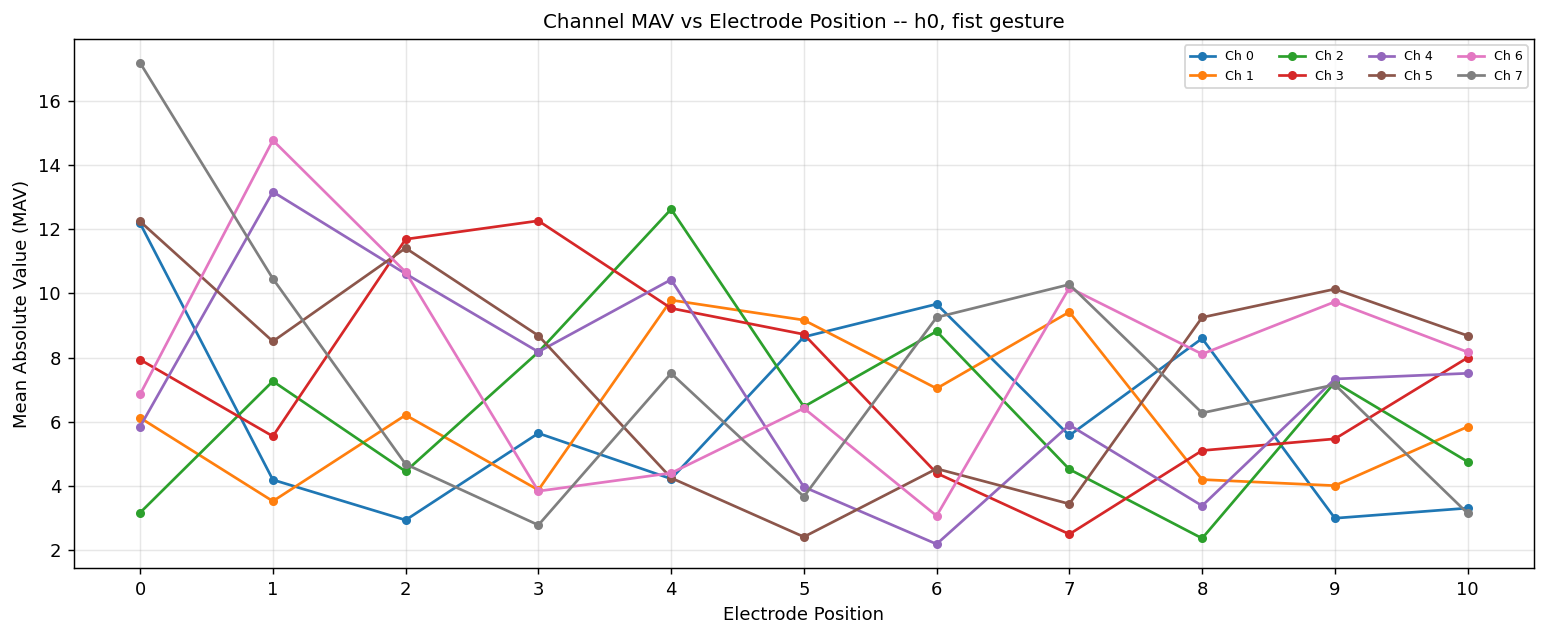

In [12]:
sample_subj = "h0"
mav_by_pos = {}

for pos in range(11):
    rows = meta_valid[
        (meta_valid["subject"] == sample_subj) & (meta_valid["session"] == 0)
        & (meta_valid["position"] == pos) & (meta_valid["gesture"] == "fist")
    ]
    ch_mavs = np.zeros(N_CHANNELS)
    count = 0
    for _, row in rows.iterrows():
        try:
            w, _ = load_trial_windows(row["window_file_path"])
            ch_mavs += np.mean(np.abs(w), axis=(0, 2))
            count += 1
        except Exception:
            continue
    if count > 0:
        mav_by_pos[pos] = ch_mavs / count

fig, ax = plt.subplots(figsize=(12, 5))
positions = sorted(mav_by_pos.keys())
for ch in range(N_CHANNELS):
    values = [mav_by_pos[p][ch] for p in positions]
    ax.plot(positions, values, "o-", label=f"Ch {ch}", markersize=4, linewidth=1.5)

ax.set_xlabel("Electrode Position")
ax.set_ylabel("Mean Absolute Value (MAV)")
ax.set_title(f"Channel MAV vs Electrode Position -- {sample_subj}, fist gesture")
ax.legend(fontsize=7, ncol=4)
ax.set_xticks(positions)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Inter-Day Variability

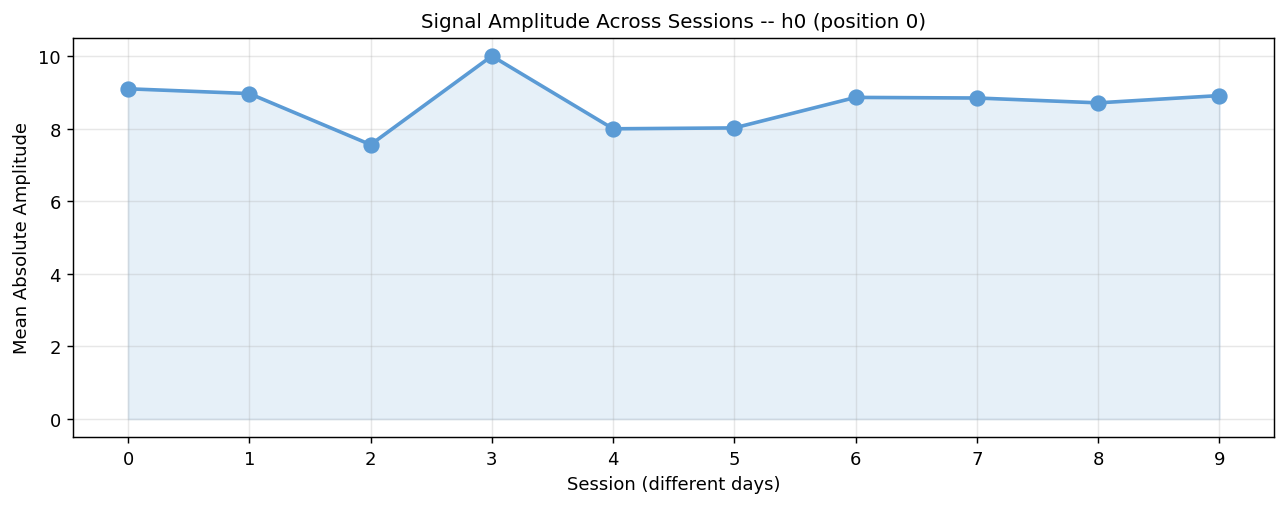

Session 0 amplitude: 9.105
Max amplitude: 10.009 (session 3)
Min amplitude: 7.564 (session 2)
Variation (max/min): 1.32x


In [13]:
subj = "h0"
sess_amps = {}

for sess in range(10):
    rows = meta_valid[
        (meta_valid["subject"] == subj) & (meta_valid["session"] == sess)
        & (meta_valid["position"] == 0)
    ]
    if len(rows) == 0:
        continue
    amps = []
    for _, row in rows.iterrows():
        try:
            w, _ = load_trial_windows(row["window_file_path"])
            amps.append(np.mean(np.abs(w)))
        except Exception:
            continue
    if amps:
        sess_amps[sess] = np.mean(amps)

fig, ax = plt.subplots(figsize=(10, 4))
sessions = sorted(sess_amps.keys())
values = [sess_amps[s] for s in sessions]
ax.plot(sessions, values, "o-", color="#5B9BD5", linewidth=2, markersize=8)
ax.fill_between(sessions, values, alpha=0.15, color="#5B9BD5")
ax.set_xlabel("Session (different days)")
ax.set_ylabel("Mean Absolute Amplitude")
ax.set_title(f"Signal Amplitude Across Sessions -- {subj} (position 0)")
ax.set_xticks(sessions)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if len(values) > 1:
    print(f"Session 0 amplitude: {values[0]:.3f}")
    print(f"Max amplitude: {max(values):.3f} (session {sessions[values.index(max(values))]})")
    print(f"Min amplitude: {min(values):.3f} (session {sessions[values.index(min(values))]})")
    print(f"Variation (max/min): {max(values)/min(values):.2f}x")

## 10. Fatigue Effect on Signal

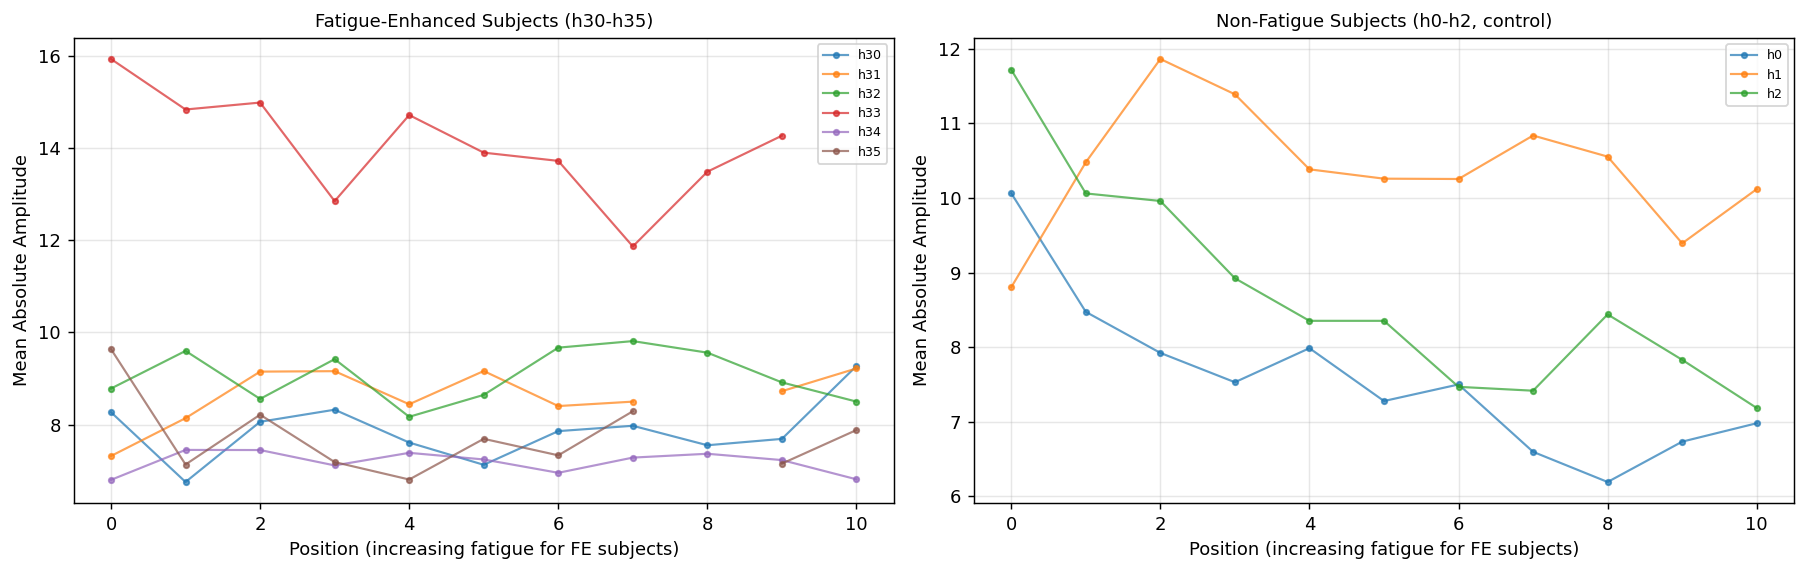

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

fat_subjs = sorted(SUBJECTS_FATIGUE)
nonfat_subjs = ["h0", "h1", "h2"]

for ax, subj_list, title, color in [
    (axes[0], fat_subjs, "Fatigue-Enhanced Subjects (h30-h35)", "#ED7D31"),
    (axes[1], nonfat_subjs, "Non-Fatigue Subjects (h0-h2, control)", "#5B9BD5"),
]:
    for subj in subj_list:
        pos_amps = {}
        for pos in range(11):
            rows = meta_valid[
                (meta_valid["subject"] == subj) & (meta_valid["session"] == 0)
                & (meta_valid["position"] == pos)
            ]
            if len(rows) == 0:
                continue
            amps = []
            for _, row in rows.head(7).iterrows():
                try:
                    w, _ = load_trial_windows(row["window_file_path"])
                    amps.append(np.mean(np.abs(w)))
                except Exception:
                    continue
            if amps:
                pos_amps[pos] = np.mean(amps)
        if pos_amps:
            positions = sorted(pos_amps.keys())
            ax.plot(positions, [pos_amps[p] for p in positions],
                    "o-", label=subj, alpha=0.7, markersize=3, linewidth=1.2)

    ax.set_xlabel("Position (increasing fatigue for FE subjects)")
    ax.set_ylabel("Mean Absolute Amplitude")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Channel Correlation Analysis

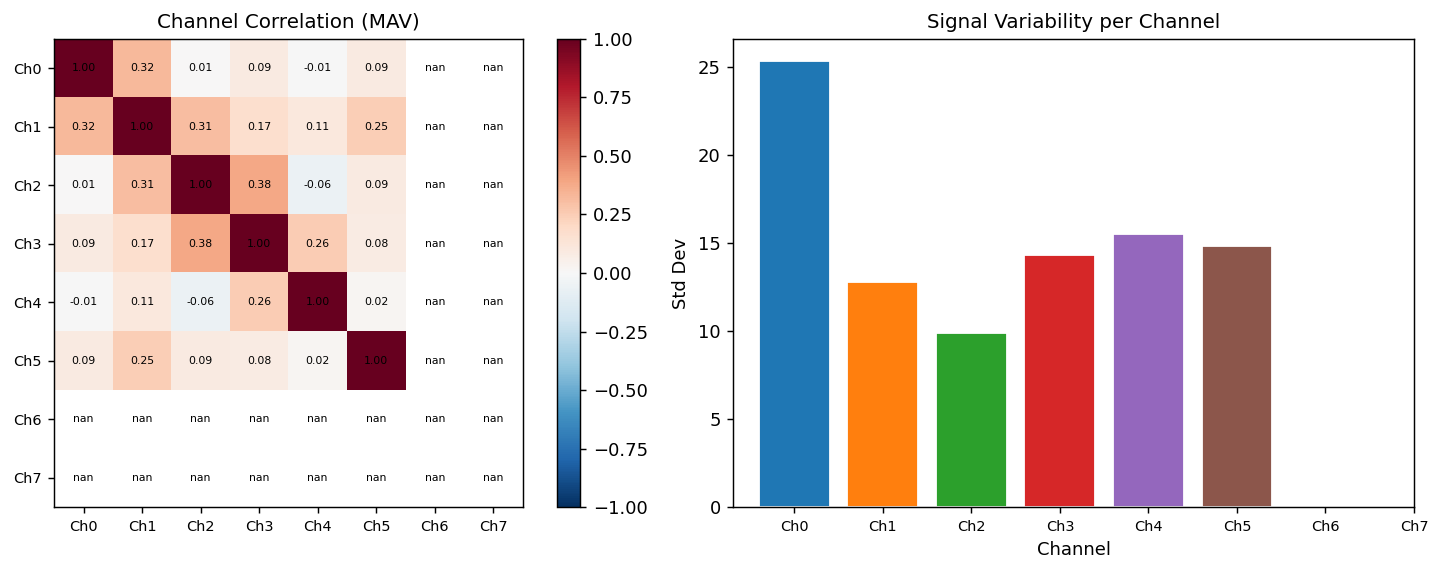

In [16]:
n_samples_corr = 500
rows_sample = meta_valid[
    (meta_valid["session"] == 0) & (meta_valid["position"] == 0) & (meta_valid["repetition"] == 0)
]
rows_sample = rows_sample.sample(n=min(n_samples_corr, len(rows_sample)), random_state=42)

all_windows = []
for _, row in rows_sample.iterrows():
    try:
        w, _ = load_trial_windows(row["window_file_path"])
        all_windows.append(w[len(w)//2])
    except Exception:
        continue

stacked = np.stack(all_windows)

corr_ch = np.corrcoef(stacked.mean(axis=2).T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im = axes[0].imshow(corr_ch, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title("Channel Correlation (MAV)")
axes[0].set_xticks(range(N_CHANNELS))
axes[0].set_yticks(range(N_CHANNELS))
axes[0].set_xticklabels([f"Ch{i}" for i in range(N_CHANNELS)], fontsize=8)
axes[0].set_yticklabels([f"Ch{i}" for i in range(N_CHANNELS)], fontsize=8)
for i in range(N_CHANNELS):
    for j in range(N_CHANNELS):
        axes[0].text(j, i, f"{corr_ch[i,j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=axes[0], fraction=0.046)

ch_stds = np.std(stacked, axis=(0, 2))
axes[1].bar(range(N_CHANNELS), ch_stds, color=palette[:N_CHANNELS], edgecolor="white")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Std Dev")
axes[1].set_title("Signal Variability per Channel")
axes[1].set_xticks(range(N_CHANNELS))
axes[1].set_xticklabels([f"Ch{i}" for i in range(N_CHANNELS)], fontsize=8)

plt.tight_layout()
plt.show()

## 12. Feature Space Analysis

### 12.1 Time-Domain Feature Distribution by Gesture

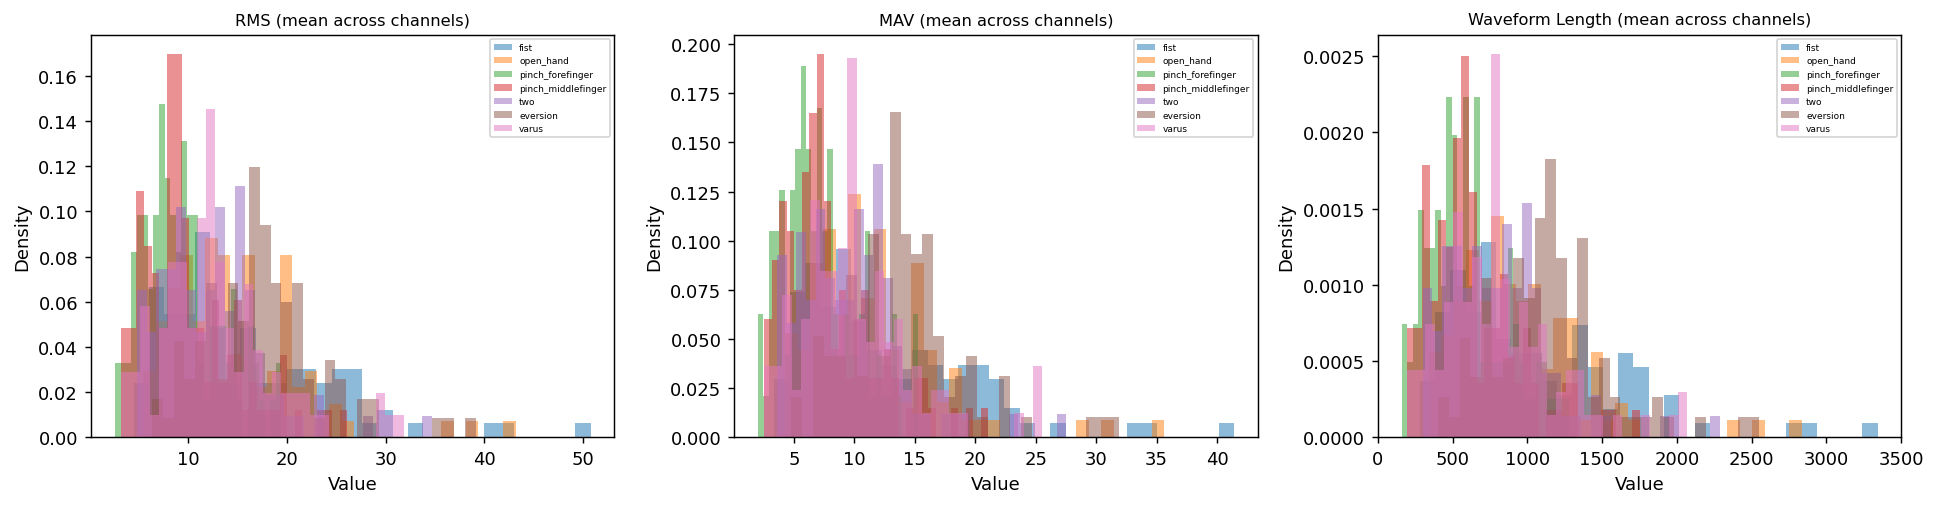

In [18]:
from src.feature_extraction import _rms, _mav, _waveform_length, _zero_crossings

n_feat_samples = 2000
feat_rows = meta_valid[
    (meta_valid["session"] == 0) & (meta_valid["position"] == 0)
]
feat_rows = feat_rows.sample(n=min(n_feat_samples, len(feat_rows)), random_state=42)

records = []
for _, row in feat_rows.iterrows():
    try:
        w, labels = load_trial_windows(row["window_file_path"])
        mid = len(w) // 2
        win = w[mid]
        rms_vals = [_rms(win[ch]) for ch in range(N_CHANNELS)]
        mav_vals = [_mav(win[ch]) for ch in range(N_CHANNELS)]
        wl_vals = [_waveform_length(win[ch]) for ch in range(N_CHANNELS)]
        records.append({
            "gesture": row["gesture"],
            "subject": row["subject"],
            "label": int(labels[mid]),
            "rms_mean": np.mean(rms_vals),
            "mav_mean": np.mean(mav_vals),
            "wl_mean": np.mean(wl_vals),
        })
    except Exception:
        continue

feat_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat, title in [
    (axes[0], "rms_mean", "RMS (mean across channels)"),
    (axes[1], "mav_mean", "MAV (mean across channels)"),
    (axes[2], "wl_mean", "Waveform Length (mean across channels)"),
]:
    for gesture_name, label in sorted(GESTURE_TO_LABEL.items(), key=lambda x: x[1]):
        subset = feat_df[feat_df["gesture"] == gesture_name][feat]
        if len(subset) > 0:
            ax.hist(subset, bins=30, alpha=0.5, label=gesture_name, density=True)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=5, loc="upper right")

plt.tight_layout()
plt.show()

### 12.2 Feature Space Visualization (PCA)

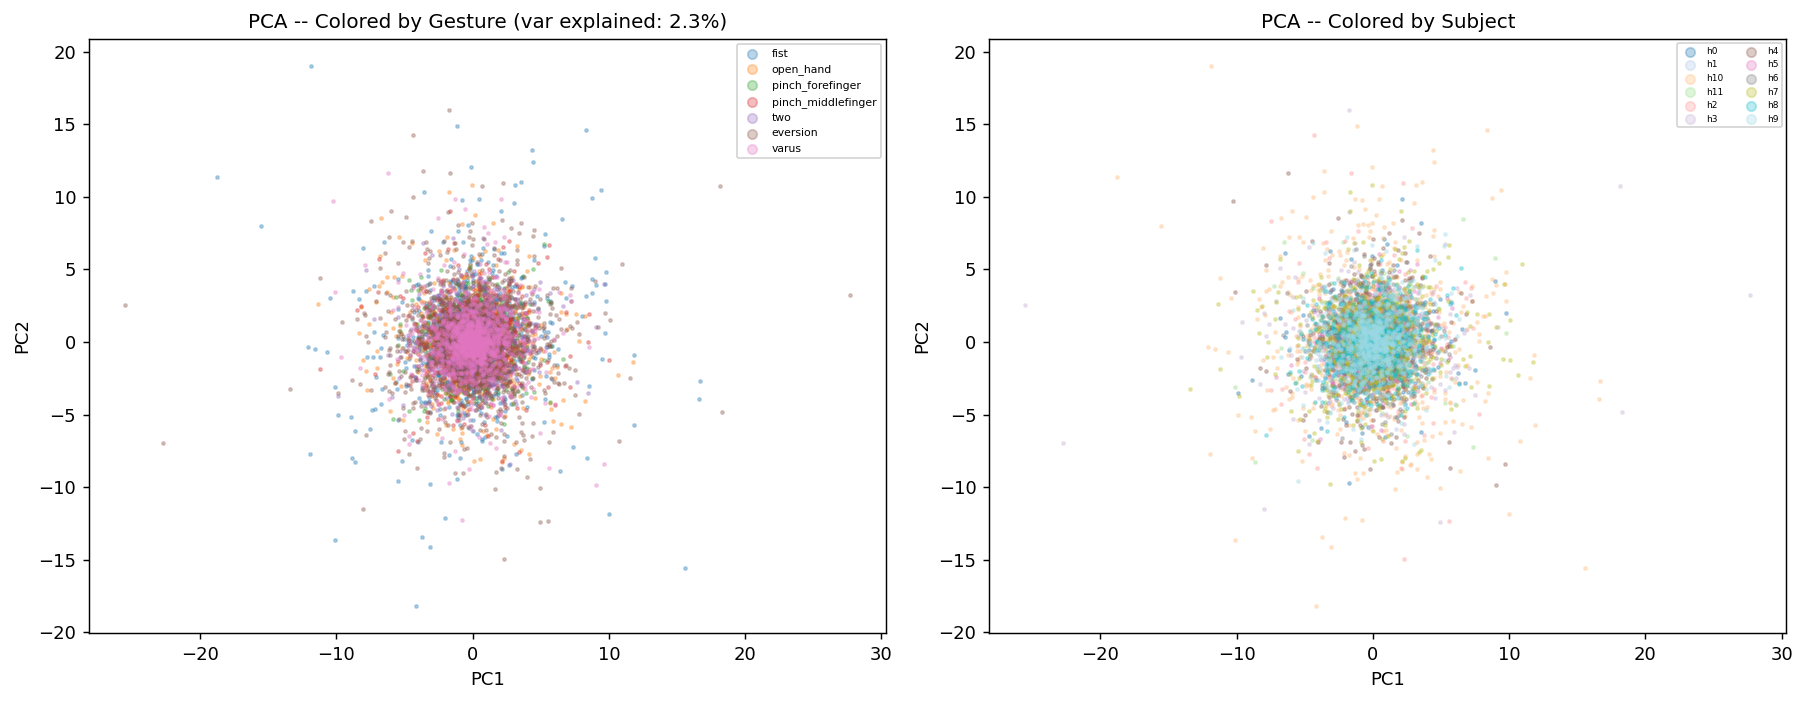

Observation: If subject clusters are clearly separated, it indicates
high inter-subject variability -- a key challenge for cross-subject models.


In [19]:
from sklearn.decomposition import PCA
from src.data_splitter import load_windows_from_metadata, compute_normalization_stats, apply_normalization

viz_rows = meta_valid[
    (meta_valid["session"] == 0) & (meta_valid["position"] == 0) & (meta_valid["repetition"] == 0)
]
subjects_viz = sorted(viz_rows["subject"].unique(), key=lambda x: int(x[1:]))[:12]
viz_rows = viz_rows[viz_rows["subject"].isin(subjects_viz)]

X_viz, y_viz = load_windows_from_metadata(viz_rows, verbose=False)
mean, std = compute_normalization_stats(X_viz)
X_viz = apply_normalization(X_viz, mean, std)

X_flat = X_viz.reshape(len(X_viz), -1)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

subj_labels = []
for _, row in viz_rows.iterrows():
    w, _ = load_trial_windows(row["window_file_path"])
    subj_labels.extend([row["subject"]] * len(w))
subj_labels = np.array(subj_labels)[:len(X_pca)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

gesture_names = {v: k for k, v in GESTURE_TO_LABEL.items()}
for label in np.unique(y_viz):
    mask = y_viz[:len(X_pca)] == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=3, alpha=0.3,
                    label=gesture_names.get(label, str(label)))
axes[0].set_title(f"PCA -- Colored by Gesture (var explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=6, markerscale=3, loc="upper right")

unique_subjs = sorted(set(subj_labels))[:12]
cmap = plt.cm.tab20(np.linspace(0, 1, len(unique_subjs)))
for idx, subj in enumerate(unique_subjs):
    mask = subj_labels == subj
    if mask.sum() > 0:
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=3, alpha=0.3,
                        color=cmap[idx], label=subj)
axes[1].set_title("PCA -- Colored by Subject")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=5, markerscale=3, loc="upper right", ncol=2)

plt.tight_layout()
plt.show()

print("Observation: If subject clusters are clearly separated, it indicates")
print("high inter-subject variability -- a key challenge for cross-subject models.")

### 12.3 Electrode Shift Effect in Feature Space

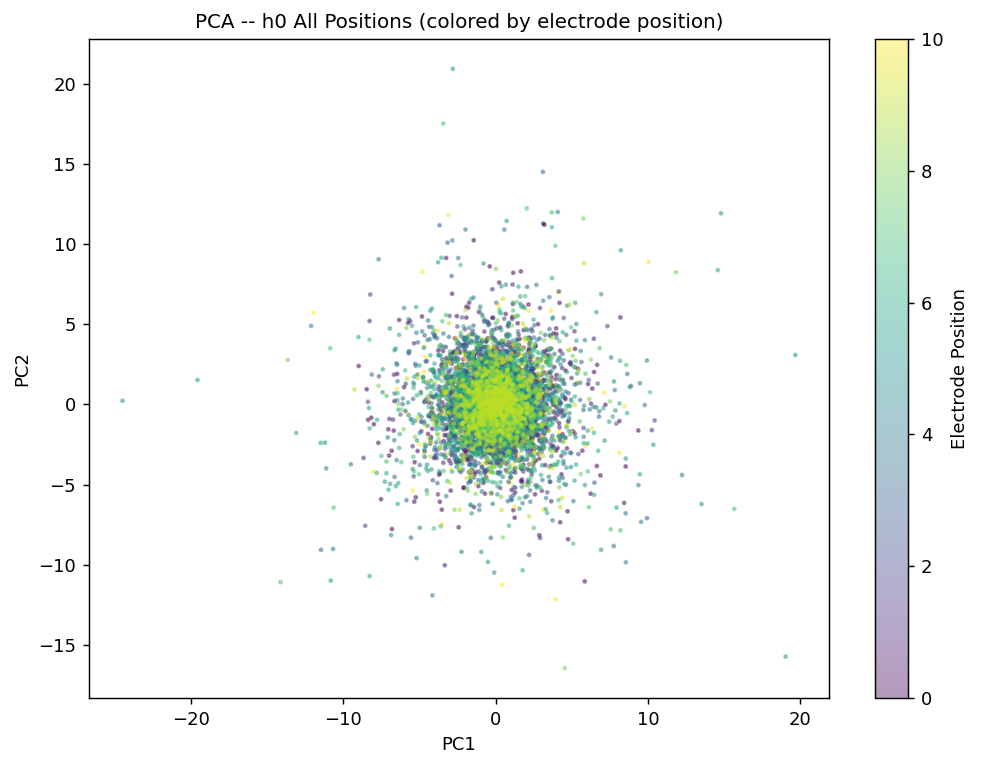

Observation: Position-dependent clustering shows that electrode shift
creates distinct distributions -- explaining accuracy degradation in S2/S7.


In [20]:
viz_shift = meta_valid[
    (meta_valid["subject"] == "h0") & (meta_valid["session"] == 0) & (meta_valid["repetition"] == 0)
]

X_shift, y_shift = load_windows_from_metadata(viz_shift, verbose=False)
mean_s, std_s = compute_normalization_stats(X_shift)
X_shift = apply_normalization(X_shift, mean_s, std_s)

X_shift_flat = X_shift.reshape(len(X_shift), -1)
pca_shift = PCA(n_components=2, random_state=42)
X_pca_shift = pca_shift.fit_transform(X_shift_flat)

pos_labels = []
for _, row in viz_shift.iterrows():
    w, _ = load_trial_windows(row["window_file_path"])
    pos_labels.extend([row["position"]] * len(w))
pos_labels = np.array(pos_labels)[:len(X_pca_shift)]

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca_shift[:, 0], X_pca_shift[:, 1],
                     c=pos_labels, cmap="viridis", s=3, alpha=0.4)
plt.colorbar(scatter, ax=ax, label="Electrode Position")
ax.set_title("PCA -- h0 All Positions (colored by electrode position)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

print("Observation: Position-dependent clustering shows that electrode shift")
print("creates distinct distributions -- explaining accuracy degradation in S2/S7.")

## 13. Summary Statistics

In [21]:
print("=" * 70)
print("  DATASET SUMMARY FOR PAPER")
print("=" * 70)

n_subj = meta_valid["subject"].nunique()
n_trials = len(meta_valid)
n_windows_total = int(meta_valid["n_windows"].sum())
n_gestures = meta_valid["gesture"].nunique()

interday_long = meta_valid[meta_valid["subject"].isin(SUBJECTS_INTERDAY_LONG)]
interday_short = meta_valid[meta_valid["subject"].isin(SUBJECTS_INTERDAY_SHORT)]
fatigue = meta_valid[meta_valid["subject"].isin(SUBJECTS_FATIGUE)]

print(f"  Total subjects:              {n_subj}")
print(f"  Total valid trials:          {n_trials:,}")
print(f"  Total windows:               {n_windows_total:,}")
print(f"  Gestures:                    {n_gestures}")
print(f"  Channels:                    {N_CHANNELS}")
print(f"  Sampling rate:               {SAMPLING_RATE} Hz")
print(f"  Window:                      {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLING_RATE*1000:.0f} ms)")
print(f"  Stride:                      {STRIDE_SIZE} samples ({STRIDE_SIZE/SAMPLING_RATE*1000:.0f} ms)")
print(f"  ---")
print(f"  Interday-long subjects:      {len(SUBJECTS_INTERDAY_LONG)} ({', '.join(SUBJECTS_INTERDAY_LONG)})")
print(f"  Interday-short subjects:     {len(SUBJECTS_INTERDAY_SHORT)} ({', '.join(SUBJECTS_INTERDAY_SHORT)})")
print(f"  Fatigue subjects:            {len(SUBJECTS_FATIGUE)} ({', '.join(sorted(SUBJECTS_FATIGUE))})")
print(f"  Single-session subjects:     {n_subj - len(SUBJECTS_INTERDAY_LONG) - len(SUBJECTS_INTERDAY_SHORT) - len(SUBJECTS_FATIGUE)}")
print(f"  ---")
print(f"  Gestures: {list(GESTURE_TO_LABEL.keys())}")
print("=" * 70)

trials_per_gesture = meta_valid.groupby("gesture").size()
windows_per_gesture = meta_valid.groupby("gesture")["n_windows"].sum()
print("\nPer-gesture breakdown:")
print(f"{'Gesture':<22} {'Trials':>8} {'Windows':>10} {'Pct':>6}")
print("-" * 48)
for gesture in sorted(GESTURE_TO_LABEL.keys(), key=lambda g: GESTURE_TO_LABEL[g]):
    t = trials_per_gesture.get(gesture, 0)
    w = windows_per_gesture.get(gesture, 0)
    pct = w / n_windows_total * 100
    print(f"{gesture:<22} {t:>8,} {int(w):>10,} {pct:>5.1f}%")
print("-" * 48)
print(f"{'TOTAL':<22} {n_trials:>8,} {n_windows_total:>10,} {'100.0':>5}%")

  DATASET SUMMARY FOR PAPER
  Total subjects:              36
  Total valid trials:          24,457
  Total windows:               2,792,999
  Gestures:                    7
  Channels:                    8
  Sampling rate:               200 Hz
  Window:                      50 samples (250 ms)
  Stride:                      10 samples (50 ms)
  ---
  Interday-long subjects:      6 (h0, h1, h2, h3, h4, h5)
  Interday-short subjects:     8 (h6, h7, h8, h9, h10, h11, h12, h13)
  Fatigue subjects:            6 (h30, h31, h32, h33, h34, h35)
  Single-session subjects:     16
  ---
  Gestures: ['fist', 'open_hand', 'pinch_forefinger', 'pinch_middlefinger', 'two', 'eversion', 'varus']

Per-gesture breakdown:
Gesture                  Trials    Windows    Pct
------------------------------------------------
fist                      3,494    398,551  14.3%
open_hand                 3,494    398,457  14.3%
pinch_forefinger          3,491    399,422  14.3%
pinch_middlefinger        3,495    399,

## 14. Key Findings for Model Design

**Inter-Subject Variability**: Signal amplitudes vary significantly across subjects (CV shown above). This confirms the need for normalization and motivates the pooled model + calibration approach.

**Electrode Shift**: Channel activation patterns change drastically with rotation. PCA shows position-dependent clusters. Channel rotation augmentation during training is strongly motivated by this finding.

**Inter-Day Drift**: Session-to-session amplitude variation exists even for the same subject at the same position. BatchNorm adaptation during calibration is motivated by this observation.

**Fatigue Effect**: Fatigue-enhanced subjects show gradual signal changes across positions (after exercise), confirming that temporal adaptation is needed.

**Class Balance**: The dataset is relatively balanced across gestures, so class-weighted loss is not strictly necessary.

**Feature Space**: PCA colored by subject shows clear subject-specific clusters, confirming that raw features carry strong subject identity. The model must learn to extract subject-invariant gesture features.